# Oasis Infobyte Data Science Internship - Task 2
##  Unemployment analysis  with python
*Objective* : Perform exploratory data analysis on unemployment data to uncover regional 
and temporal trends, with a focus on the impact of the COVID-19 pandemic on 
unemployment rates in India

## Importing Libraries

In [329]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [330]:
df = pd.read_csv("C:\\Users\\k2640\\Downloads\\Unemployment in India.csv")

In [331]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [332]:
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [333]:
print("\nDataset shape:", df.shape)


Dataset shape: (768, 7)


In [334]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [335]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


# Data Cleaning

In [336]:
df.columns = df.columns.str.strip()
df = df.dropna(axis=1, how="all")


column_mapping = {
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate"
}

df = df.rename(columns=column_mapping)

In [359]:
required_columns = [
    "Region",
    "Date",
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("\nERROR: These required columns are missing:")
    print(missing_columns)
    print("\nAvailable columns:")
    print(df.columns.tolist())
    raise SystemExit

In [338]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    dayfirst=True
)


print(df["Date"].dtype)

datetime64[us]


# Type Conversion 

##  Convert numeric columns to numbers

In [339]:
numeric_columns = [
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

## Removing rows where important values are missing

In [340]:

df = df.dropna(
    subset=[
        "Region",
        "Date",
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]
)

In [341]:
df["Region"] = df["Region"].astype(str).str.strip()


## Sort by date

In [342]:
df = df.sort_values("Date").reset_index(drop=True)

In [343]:
print(df.head())

           Region       Date Frequency  Unemployment_Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1       Telangana 2019-05-31   Monthly               2.23  11053353.0   
2      Tamil Nadu 2019-05-31   Monthly               0.97  15844698.0   
3       Rajasthan 2019-05-31   Monthly               4.03  15226005.0   
4          Punjab 2019-05-31   Monthly               9.17   6088547.0   

   Labour_Participation_Rate   Area  
0                      43.24  Rural  
1                      61.74  Rural  
2                      49.44  Rural  
3                      38.52  Rural  
4                      44.79  Rural  


In [344]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64


In [345]:
print("\nData types:")
print(df.dtypes)



Data types:
Region                                  str
Date                         datetime64[us]
Frequency                               str
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                    str
dtype: object


##  Save cleaned dataset

In [346]:
df.to_csv(
    os.path.join(OUTPUT_DIR, "cleaned_unemployment_data.csv"),
    index=False
)

In [347]:

def save_and_show(filename):
    """
    Saves the current chart inside the output folder
    and displays it.
    """
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, filename),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

## Region-wise average unemployment rate


========== REGION-WISE AVERAGE ==========
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Unemployment_Rate, dtype: float64


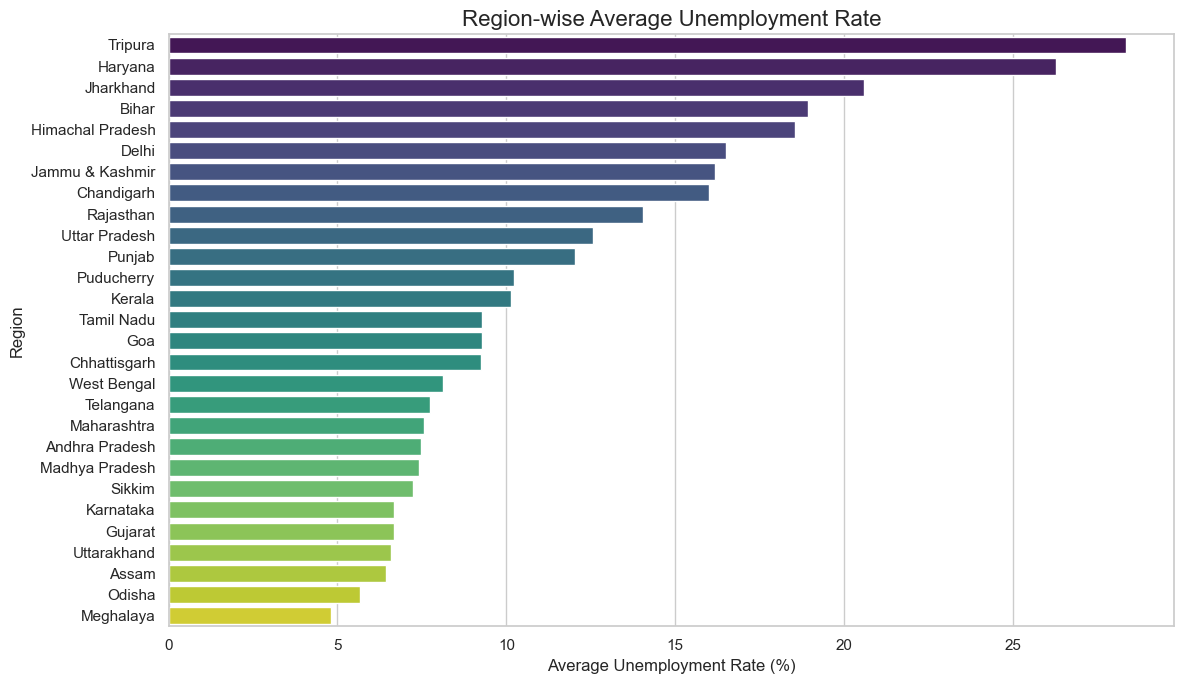

In [348]:
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
)

print("\n========== REGION-WISE AVERAGE ==========")
print(region_avg)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index,
    hue=region_avg.index,
    palette="viridis",
    legend=False
)

plt.title("Region-wise Average Unemployment Rate", fontsize=16)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

save_and_show("01_region_wise_average.png")

##  Written observation

In [349]:
highest_region = region_avg.idxmax()
lowest_region = region_avg.idxmin()

observation_1 = (
    f"Observation 1:\n"
    f"- {highest_region} has the highest average unemployment rate "
    f"({region_avg.max():.2f}%).\n"
    f"- {lowest_region} has the lowest average unemployment rate "
    f"({region_avg.min():.2f}%).\n"
    f"- This indicates that unemployment varies across regions."
)

print("\n" + observation_1)



Observation 1:
- Tripura has the highest average unemployment rate (28.35%).
- Meghalaya has the lowest average unemployment rate (4.80%).
- This indicates that unemployment varies across regions.


## Month-wise average unemployment rate


========== MONTH-WISE AVERAGE ==========
Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Unemployment_Rate, dtype: float64


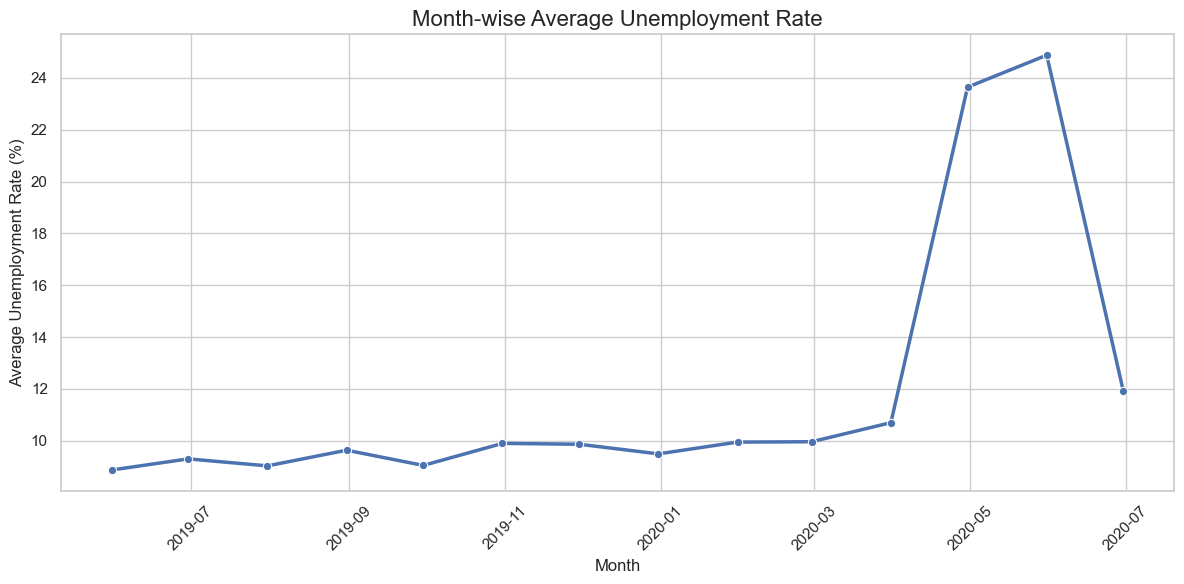

In [350]:
monthly_avg = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean()
    .sort_index()
)

print("\n========== MONTH-WISE AVERAGE ==========")
print(monthly_avg)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker="o",
    linewidth=2.5
)

plt.title("Month-wise Average Unemployment Rate", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

save_and_show("02_month_wise_trend.png")

##  Written observation

In [351]:
highest_month = monthly_avg.idxmax()
lowest_month = monthly_avg.idxmin()

# Convert the index values into datetime objects
highest_month = pd.to_datetime(highest_month)
lowest_month = pd.to_datetime(lowest_month)

observation_2 = (
    f"Observation 2:\n"
    f"- The highest average unemployment rate was recorded in "
    f"{highest_month.strftime('%B %Y')} "
    f"({monthly_avg.max():.2f}%).\n"
    f"- The lowest average unemployment rate was recorded in "
    f"{lowest_month.strftime('%B %Y')} "
    f"({monthly_avg.min():.2f}%).\n"
    f"- The line chart shows how unemployment changed over time."
)

print("\n" + observation_2)


Observation 2:
- The highest average unemployment rate was recorded in May 2020 (24.88%).
- The lowest average unemployment rate was recorded in May 2019 (8.87%).
- The line chart shows how unemployment changed over time.


## Top 10 states with  highest average unemployment rate


========== TOP 10 STATES/REGIONS ==========
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64


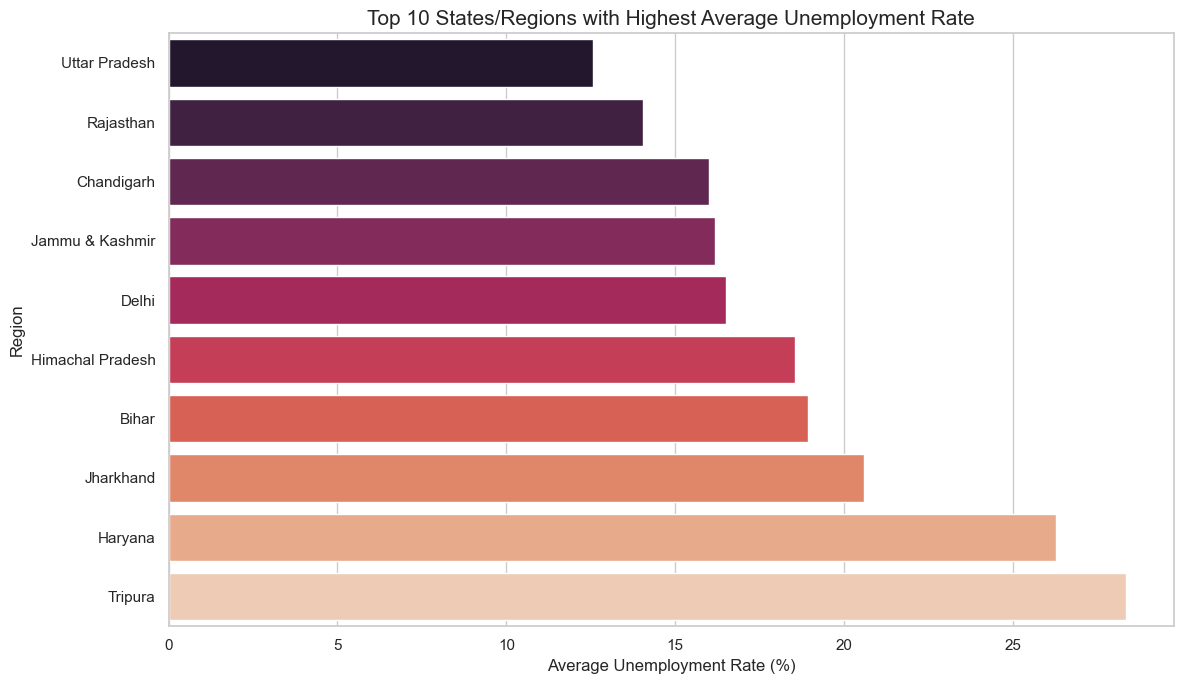

In [352]:
top_10 = region_avg.head(10).sort_values(ascending=True)

print("\n========== TOP 10 STATES/REGIONS ==========")
print(top_10.sort_values(ascending=False))

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10.values,
    y=top_10.index,
    hue=top_10.index,
    palette="rocket",
    legend=False
)

plt.title(
    "Top 10 States/Regions with Highest Average Unemployment Rate",
    fontsize=15
)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

save_and_show("03_top_10_unemployment_regions.png")

## Written observation

In [353]:
observation_3 = (
    "Observation 3:\n"
    "- The chart displays the 10 regions with the highest "
    "average unemployment rates.\n"
    f"- {region_avg.head(3).index[0]}, "
    f"{region_avg.head(3).index[1]}, and "
    f"{region_avg.head(3).index[2]} are among the highest.\n"
    "- These regions may require closer examination of employment "
    "opportunities and economic conditions."
)

print("\n" + observation_3)


Observation 3:
- The chart displays the 10 regions with the highest average unemployment rates.
- Tripura, Haryana, and Jharkhand are among the highest.
- These regions may require closer examination of employment opportunities and economic conditions.


## Correlation heatmap


========== CORRELATION MATRIX ==========
                           Unemployment_Rate  Employed  \
Unemployment_Rate                   1.000000 -0.222876   
Employed                           -0.222876  1.000000   
Labour_Participation_Rate           0.002558  0.011300   

                           Labour_Participation_Rate  
Unemployment_Rate                           0.002558  
Employed                                    0.011300  
Labour_Participation_Rate                   1.000000  


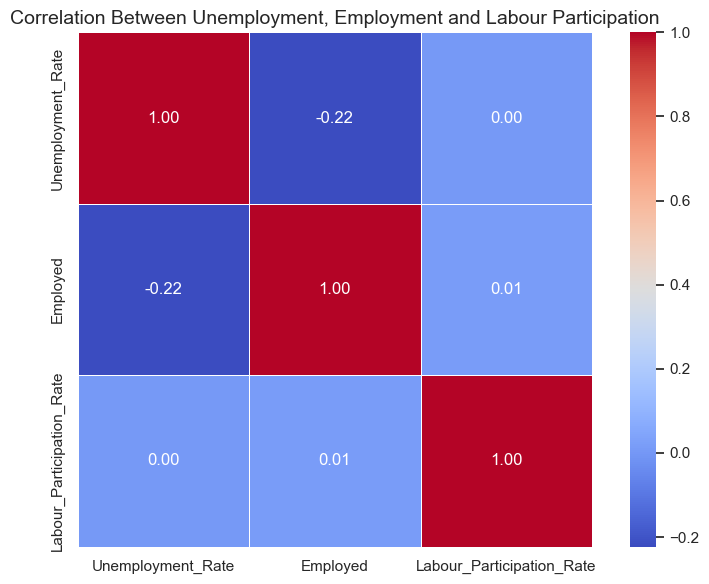

In [354]:
correlation_columns = [
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate"
]

correlation_matrix = df[correlation_columns].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Between Unemployment, Employment and Labour Participation",
    fontsize=14
)

save_and_show("04_correlation_heatmap.png")

## Written observation

In [355]:
observation_4 = (
    "Observation 4:\n"
    "- The heatmap shows the correlation between unemployment rate, "
    "estimated employment, and labour participation rate.\n"
    "- A positive correlation means both variables tend to increase "
    "together, while a negative correlation means one tends to decrease "
    "when the other increases.\n"
    "- Correlation does not prove that one variable causes another."
)

print("\n" + observation_4)


Observation 4:
- The heatmap shows the correlation between unemployment rate, estimated employment, and labour participation rate.
- A positive correlation means both variables tend to increase together, while a negative correlation means one tends to decrease when the other increases.
- Correlation does not prove that one variable causes another.


## Pre-Covid VS Covid/Lockdown comparision
India announced the nationwide COVID-19 lockdown beginning
 on 25 March 2020.

 IMPORTANT:
 This dataset generally covers a short period around 2019-2020.
 Therefore, it may not contain a true post-pandemic period.
 Here we compare:
   Pre-COVID: before 25 March 2020
   COVID/Lockdown: 25 March 2020 onwards

 If your teacher specifically wants "Post-COVID", rename the
 second label only if your dataset contains later dates.



========== PRE-COVID VS COVID/LOCKDOWN ==========
Period
Pre-COVID          9.509534
COVID/Lockdown    17.774363
Name: Unemployment_Rate, dtype: float64


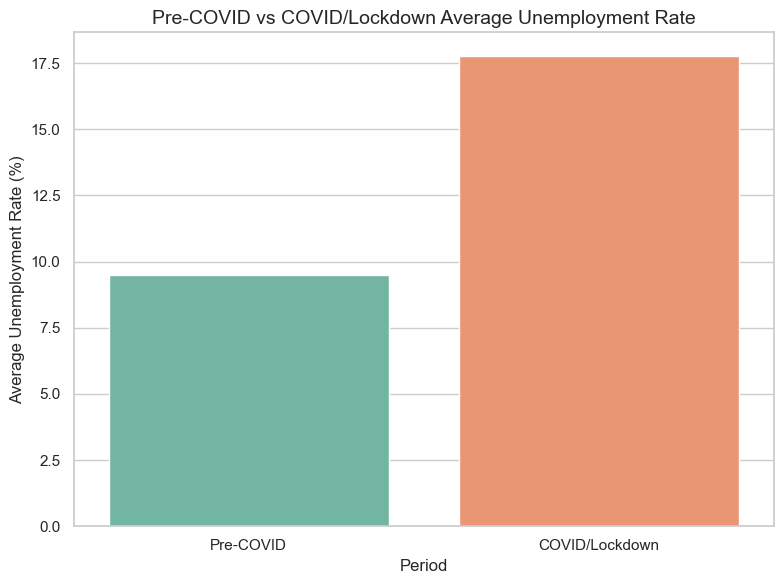

In [356]:

COVID_DATE = pd.Timestamp("2020-03-25")

df["Period"] = df["Date"].apply(
    lambda date: "Pre-COVID" if date < COVID_DATE
    else "COVID/Lockdown"
)

period_avg = (
    df.groupby("Period")["Unemployment_Rate"]
    .mean()
    .reindex(["Pre-COVID", "COVID/Lockdown"])
)

print("\n========== PRE-COVID VS COVID/LOCKDOWN ==========")
print(period_avg)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=period_avg.index,
    y=period_avg.values,
    hue=period_avg.index,
    palette="Set2",
    legend=False
)

plt.title(
    "Pre-COVID vs COVID/Lockdown Average Unemployment Rate",
    fontsize=14
)
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

save_and_show("05_pre_covid_vs_covid.png")

## Calculate percentage-point change

In [357]:
if len(period_avg.dropna()) == 2:
    change = (
        period_avg["COVID/Lockdown"]
        - period_avg["Pre-COVID"]
    )

    observation_5 = (
        "Observation 5:\n"
        f"- Pre-COVID average unemployment rate: "
        f"{period_avg['Pre-COVID']:.2f}%.\n"
        f"- COVID/Lockdown average unemployment rate: "
        f"{period_avg['COVID/Lockdown']:.2f}%.\n"
        f"- Change: {change:+.2f} percentage points.\n"
        "- This comparison shows the difference between the two "
        "periods in the available dataset."
    )

    print("\n" + observation_5)
else:
    observation_5 = (
        "Observation 5:\n"
        "- Both periods do not contain enough data for comparison."
    )
    print("\n" + observation_5)


Observation 5:
- Pre-COVID average unemployment rate: 9.51%.
- COVID/Lockdown average unemployment rate: 17.77%.
- Change: +8.26 percentage points.
- This comparison shows the difference between the two periods in the available dataset.


## Save all written observation

In [358]:
all_observations = "\n\n".join([
    observation_1,
    observation_2,
    observation_3,
    observation_4,
    observation_5
])

with open(
    os.path.join(OUTPUT_DIR, "observations.txt"),
    "w",
    encoding="utf-8"
) as file:
    file.write(all_observations)

print("\n==============================================")
print("PROJECT COMPLETED SUCCESSFULLY!")
print("Charts and cleaned data are saved in the output folder.")
print("Observations are saved in output/observations.txt")
print("==============================================")


PROJECT COMPLETED SUCCESSFULLY!
Charts and cleaned data are saved in the output folder.
Observations are saved in output/observations.txt


## Conclusion

In conclusion, this project used Python-based data analysis to explore regional and time-wise unemployment trends in India. The visualizations highlighted variations in unemployment, relationships among employment indicators, and differences between pre-COVID and COVID/lockdown periods. This analysis demonstrates the importance of data cleaning, visualization, and statistical interpretation in understanding real-world economic data.


## Key Learnings

* Learned to clean and analyze real-world data using Pandas.

* Understood how to handle missing values and convert data types.

* Learned to create visualizations using Matplotlib and Seaborn.

* Analyzed unemployment trends across regions and months.

* Improved data interpretation and Python debugging skills.
